1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

2. Mount Google Drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


3.Load the Dataset

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'dataset_09_delivery_delay_risk.csv', 'sample_data']


In [ ]:
df = pd.read_csv("/content/dataset_09_delivery_delay_risk.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


4. Checking first 5 rows with columns

In [ ]:
print(df.head())

   distance_km  warehouse_load  order_hour  items_count  weather_risk  \
0         5.72               2           5            3             5   
1        27.67               3           3            1             2   
2        27.18               4           0            4             1   
3        32.02               3           2            3             1   
4        11.36               3           2            1             2   

   carrier_delay_rate  target  
0               60.59       0  
1               29.78       0  
2               60.94       0  
3               78.66       1  
4               31.25       0  


5. View the Dataset

In [ ]:
print(df)

     distance_km  warehouse_load  order_hour  items_count  weather_risk  \
0           5.72               2           5            3             5   
1          27.67               3           3            1             2   
2          27.18               4           0            4             1   
3          32.02               3           2            3             1   
4          11.36               3           2            1             2   
..           ...             ...         ...          ...           ...   
995        41.48               3           1            1             1   
996         4.24               5           3            1             5   
997        50.81               3           2            0             2   
998         7.76               2           2            1             5   
999        11.99               3           0            6             1   

     carrier_delay_rate  target  
0                 60.59       0  
1                 29.78       0

6. Check Dataset Shape

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 7


7. Check Column Names

In [ ]:
print(df.columns)

Index(['distance_km', 'warehouse_load', 'order_hour', 'items_count',
       'weather_risk', 'carrier_delay_rate', 'target'],
      dtype='object')


8. Understand the Variables

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   distance_km         1000 non-null   float64
 1   warehouse_load      1000 non-null   int64  
 2   order_hour          1000 non-null   int64  
 3   items_count         1000 non-null   int64  
 4   weather_risk        1000 non-null   int64  
 5   carrier_delay_rate  1000 non-null   float64
 6   target              1000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 54.8 KB
None


9. Check Missing Values

In [ ]:
print(df.isnull().sum())

distance_km           0
warehouse_load        0
order_hour            0
items_count           0
weather_risk          0
carrier_delay_rate    0
target                0
dtype: int64


10.  Check Duplicate Rows

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


11. Check Target Class Balance

In [ ]:
print(df["target"].value_counts())

target
0    500
1    500
Name: count, dtype: int64


 12. Target Class Percentage

In [ ]:
print(df["target"].value_counts(normalize=True) * 100)

target
0    50.0
1    50.0
Name: proportion, dtype: float64


13. Statistical Summary

In [ ]:
print(df.describe())

       distance_km  warehouse_load   order_hour  items_count  weather_risk  \
count  1000.000000     1000.000000  1000.000000  1000.000000   1000.000000   
mean     29.578510        3.085000     2.913000     2.962000      2.946000   
std      21.943768        1.754096     1.711245     1.751463      1.439846   
min       3.410000        0.000000     0.000000     0.000000      1.000000   
25%      14.807500        2.000000     2.000000     2.000000      2.000000   
50%      23.765000        3.000000     3.000000     3.000000      3.000000   
75%      36.730000        4.000000     4.000000     4.000000      4.000000   
max     162.000000       12.000000    10.000000     9.000000      5.000000   

       carrier_delay_rate      target  
count         1000.000000  1000.00000  
mean            50.068690     0.50000  
std             19.974937     0.50025  
min              0.000000     0.00000  
25%             35.387500     0.00000  
50%             50.470000     0.50000  
75%             6

14. Check for Negative Values

In [ ]:
print("Negative distance:", (df["distance_km"] < 0).sum())
print("Negative warehouse load:", (df["warehouse_load"] < 0).sum())
print("Negative order hour:", (df["order_hour"] < 0).sum())
print("Negative items count:", (df["items_count"] < 0).sum())
print("Negative weather risk:", (df["weather_risk"] < 0).sum())
print("Negative carrier delay rate:", (df["carrier_delay_rate"] < 0).sum())

Negative distance: 0
Negative warehouse load: 0
Negative order hour: 0
Negative items count: 0
Negative weather risk: 0
Negative carrier delay rate: 0


15. Check Feature Ranges

In [ ]:
print("Warehouse load range:", df["warehouse_load"].min(), "to", df["warehouse_load"].max())
print("Order hour range:", df["order_hour"].min(), "to", df["order_hour"].max())
print("Items count range:", df["items_count"].min(), "to", df["items_count"].max())
print("Weather risk range:", df["weather_risk"].min(), "to", df["weather_risk"].max())
print("Carrier delay rate range:", df["carrier_delay_rate"].min(), "to", df["carrier_delay_rate"].max())

Warehouse load range: 0 to 12
Order hour range: 0 to 10
Items count range: 0 to 9
Weather risk range: 1 to 5
Carrier delay rate range: 0.0 to 100.0


16. Check Target Values

In [ ]:
print("Unique target values:", df["target"].unique())

Unique target values: [0 1]


17.  Distribution of Distance

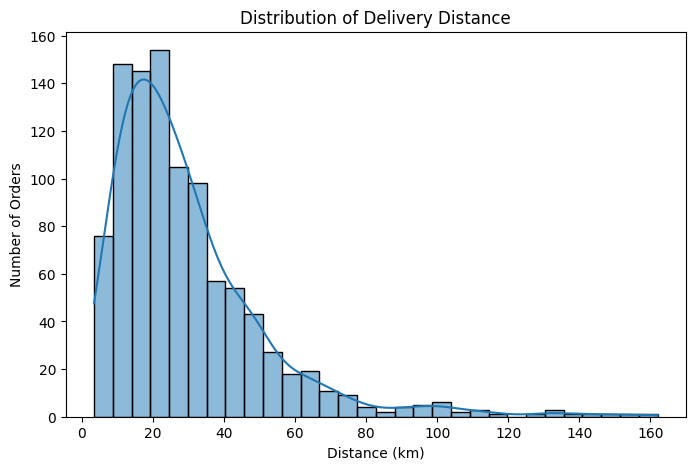

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["distance_km"], bins=30, kde=True)

plt.title("Distribution of Delivery Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Orders")
plt.show()

18. Distribution of Warehouse Load

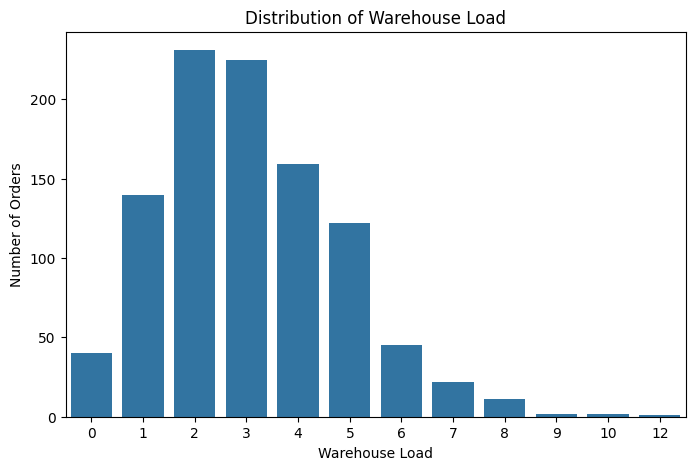

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(x=df["warehouse_load"])

plt.title("Distribution of Warehouse Load")
plt.xlabel("Warehouse Load")
plt.ylabel("Number of Orders")
plt.show()

19. Target Class Distribution

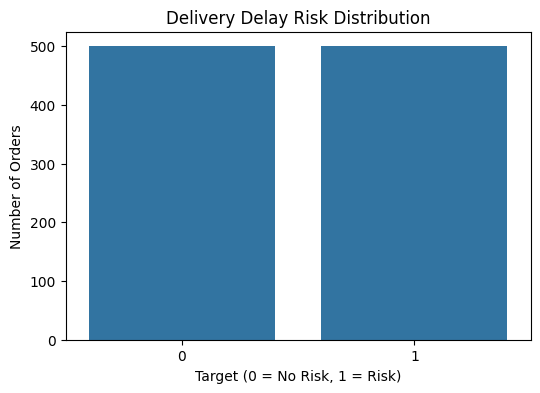

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x=df["target"])

plt.title("Delivery Delay Risk Distribution")
plt.xlabel("Target (0 = No Risk, 1 = Risk)")
plt.ylabel("Number of Orders")
plt.show()

20. Distance vs Delivery Delay Risk

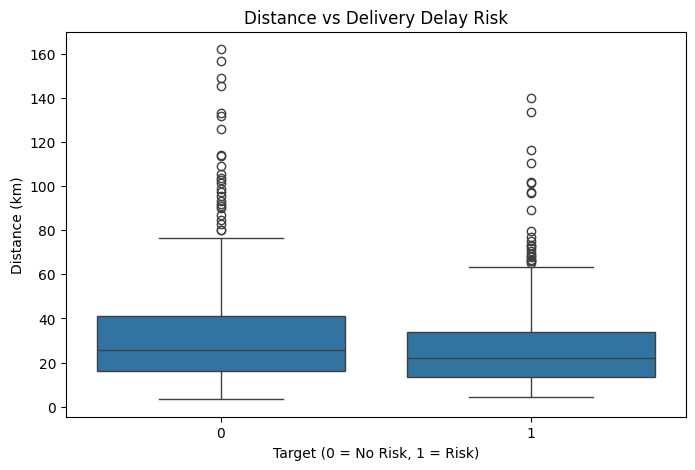

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="target", y="distance_km", data=df)

plt.title("Distance vs Delivery Delay Risk")
plt.xlabel("Target (0 = No Risk, 1 = Risk)")
plt.ylabel("Distance (km)")
plt.show()

21. Warehouse Load vs Delivery Delay Risk

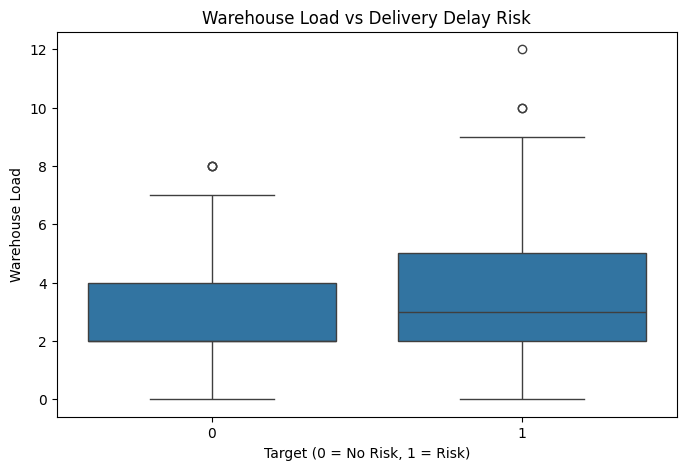

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="target", y="warehouse_load", data=df)

plt.title("Warehouse Load vs Delivery Delay Risk")
plt.xlabel("Target (0 = No Risk, 1 = Risk)")
plt.ylabel("Warehouse Load")
plt.show()

22.Weather Risk vs Delivery Delay Risk

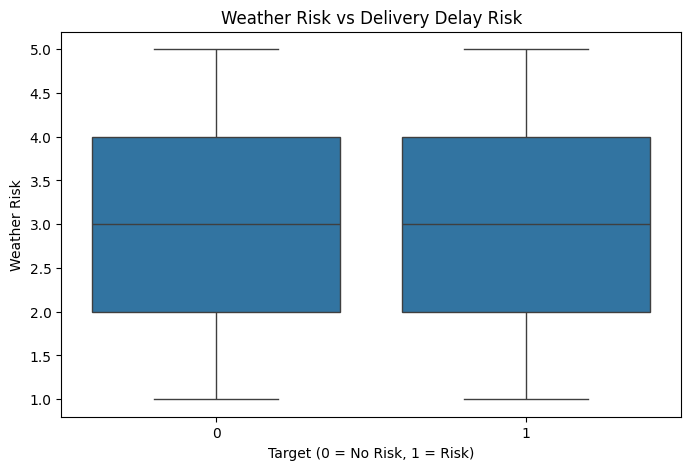

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="target", y="weather_risk", data=df)

plt.title("Weather Risk vs Delivery Delay Risk")
plt.xlabel("Target (0 = No Risk, 1 = Risk)")
plt.ylabel("Weather Risk")
plt.show()

23. Items Count vs Delivery Delay Risk

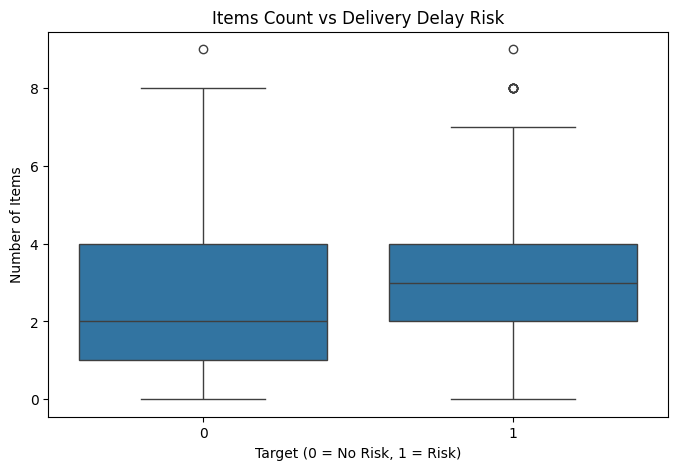

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="target", y="items_count", data=df)

plt.title("Items Count vs Delivery Delay Risk")
plt.xlabel("Target (0 = No Risk, 1 = Risk)")
plt.ylabel("Number of Items")
plt.show()

24. Carrier Delay Rate vs Delivery Delay Risk

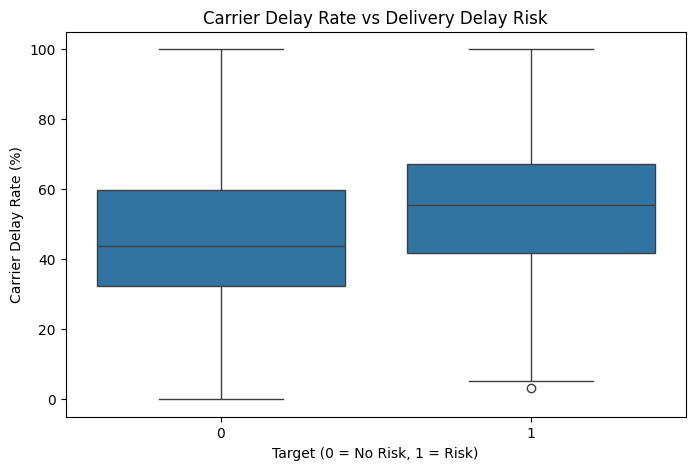

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="target", y="carrier_delay_rate", data=df)

plt.title("Carrier Delay Rate vs Delivery Delay Risk")
plt.xlabel("Target (0 = No Risk, 1 = Risk)")
plt.ylabel("Carrier Delay Rate (%)")
plt.show()

25. Order Hour vs Delivery Delay Risk

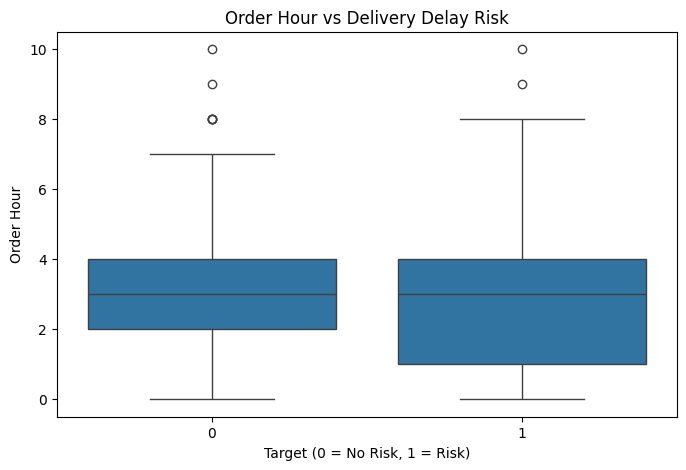

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="target", y="order_hour", data=df)

plt.title("Order Hour vs Delivery Delay Risk")
plt.xlabel("Target (0 = No Risk, 1 = Risk)")
plt.ylabel("Order Hour")
plt.show()

26. Calculate Feature Correlations

In [ ]:
correlation = df.corr(numeric_only=True)

print(correlation)

                    distance_km  warehouse_load  order_hour  items_count  \
distance_km            1.000000       -0.069151    0.020860     0.025977   
warehouse_load        -0.069151        1.000000    0.038482     0.037870   
order_hour             0.020860        0.038482    1.000000     0.033964   
items_count            0.025977        0.037870    0.033964     1.000000   
weather_risk           0.004294       -0.009675    0.007842    -0.055988   
carrier_delay_rate    -0.001612        0.020577    0.006283    -0.058417   
target                -0.123601        0.219596   -0.122194     0.205645   

                    weather_risk  carrier_delay_rate    target  
distance_km             0.004294           -0.001612 -0.123601  
warehouse_load         -0.009675            0.020577  0.219596  
order_hour              0.007842            0.006283 -0.122194  
items_count            -0.055988           -0.058417  0.205645  
weather_risk            1.000000           -0.012289 -0.115348  
c

27. Correlation with Target

In [ ]:
target_correlation = correlation["target"].sort_values(ascending=False)

print(target_correlation)

target                1.000000
carrier_delay_rate    0.228606
warehouse_load        0.219596
items_count           0.205645
weather_risk         -0.115348
order_hour           -0.122194
distance_km          -0.123601
Name: target, dtype: float64


28. Correlation Heatmap

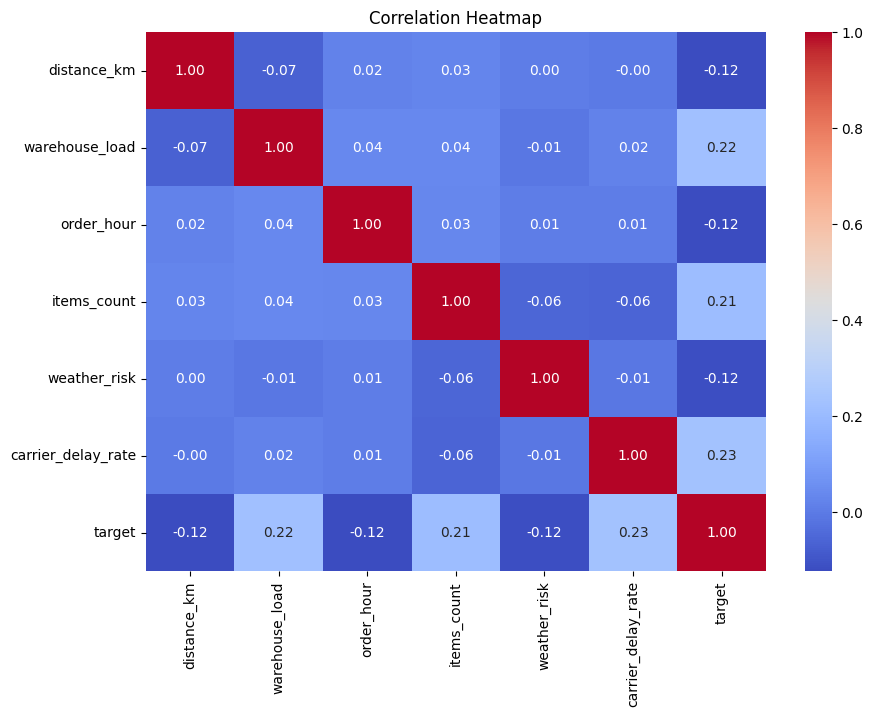

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

29. Separate Features and Target

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   distance_km  warehouse_load  order_hour  items_count  weather_risk  \
0         5.72               2           5            3             5   
1        27.67               3           3            1             2   
2        27.18               4           0            4             1   
3        32.02               3           2            3             1   
4        11.36               3           2            1             2   

   carrier_delay_rate  
0               60.59  
1               29.78  
2               60.94  
3               78.66  
4               31.25  

Target:
0    0
1    0
2    0
3    1
4    0
Name: target, dtype: int64


30. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


 31. Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


32. Create Logistic Regression Model

In [ ]:
model = LogisticRegression(random_state=42)

print(model)

LogisticRegression(random_state=42)


33. Train the Logistic Regression Model

In [ ]:
model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


34. Make Predictions

In [ ]:
y_pred = model.predict(X_test_scaled)

print("Predictions generated!")
print(y_pred[:10])

Predictions generated!
[1 0 0 0 1 1 1 1 1 1]


35. Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.625


36. Precision

In [ ]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.6126126126126126


37. Recall

In [ ]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.68


38. F1-Score

In [ ]:
f1 = f1_score(y_test, y_pred)

print("F1-Score:", f1)

F1-Score: 0.6445497630331753


 39. ROC-AUC Score

In [ ]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7145999999999999


40. Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[57 43]
 [32 68]]


41. Confusion Matrix Visualization

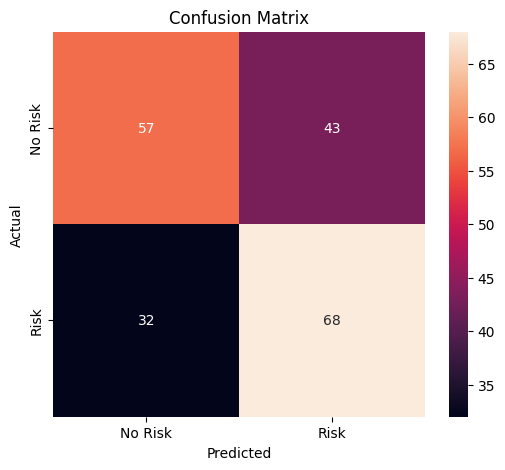

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Risk", "Risk"],
    yticklabels=["No Risk", "Risk"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

42. Classification Report

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Risk", "Risk"]
))

              precision    recall  f1-score   support

     No Risk       0.64      0.57      0.60       100
        Risk       0.61      0.68      0.64       100

    accuracy                           0.62       200
   macro avg       0.63      0.62      0.62       200
weighted avg       0.63      0.62      0.62       200



43. Model Evaluation Summary

In [ ]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

print(results)

      Metric     Score
0   Accuracy  0.625000
1  Precision  0.612613
2     Recall  0.680000
3   F1-Score  0.644550
4    ROC-AUC  0.714600


44. Logistic Regression Coefficients

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients)

              Feature  Coefficient
0         distance_km    -0.297473
1      warehouse_load     0.525193
2          order_hour    -0.345568
3         items_count     0.522863
4        weather_risk    -0.245265
5  carrier_delay_rate     0.597139


45. Feature Importance Based on Coefficients

In [ ]:
coefficients_sorted = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficients_sorted)

              Feature  Coefficient
5  carrier_delay_rate     0.597139
1      warehouse_load     0.525193
3         items_count     0.522863
4        weather_risk    -0.245265
0         distance_km    -0.297473
2          order_hour    -0.345568


46. Logistic Regression Coefficient Plot
💻 Code

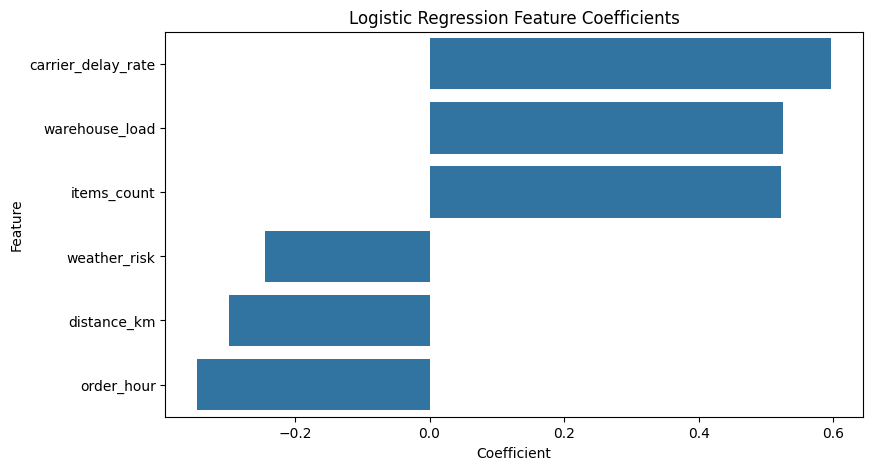

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=coefficients_sorted,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

47. Calculate Odds Ratios

In [ ]:
coefficients["Odds_Ratio"] = np.exp(coefficients["Coefficient"])

print(coefficients)

              Feature  Coefficient  Odds_Ratio
0         distance_km    -0.297473    0.742693
1      warehouse_load     0.525193    1.690785
2          order_hour    -0.345568    0.707818
3         items_count     0.522863    1.686850
4        weather_risk    -0.245265    0.782497
5  carrier_delay_rate     0.597139    1.816913


48. Positive and Negative Feature Effects

In [ ]:
positive_features = coefficients[coefficients["Coefficient"] > 0]
negative_features = coefficients[coefficients["Coefficient"] < 0]

print("Features associated with higher delay risk:")
print(positive_features)

print("\nFeatures associated with lower delay risk:")
print(negative_features)

Features associated with higher delay risk:
              Feature  Coefficient  Odds_Ratio
1      warehouse_load     0.525193    1.690785
3         items_count     0.522863    1.686850
5  carrier_delay_rate     0.597139    1.816913

Features associated with lower delay risk:
        Feature  Coefficient  Odds_Ratio
0   distance_km    -0.297473    0.742693
2    order_hour    -0.345568    0.707818
4  weather_risk    -0.245265    0.782497


49. Analyze Prediction Errors

In [ ]:
false_positives = ((y_test == 0) & (y_pred == 1)).sum()
false_negatives = ((y_test == 1) & (y_pred == 0)).sum()

print("False Positives:", false_positives)
print("False Negatives:", false_negatives)

False Positives: 43
False Negatives: 32


50. Model Limitations

The Logistic Regression model achieved an accuracy of 62.5% and a ROC-AUC of approximately 71.46%.

The main limitations are:

- The model has moderate predictive performance rather than very high accuracy.
- There are 43 false positives and 32 false negatives.
- The model uses only six input features, so other important factors affecting delivery delays may not be captured.
- The evaluation is based on a single train-test split.
- The dataset contains 1,000 records, so a larger dataset may be required for better generalization.
- Logistic Regression assumes a relatively simple relationship between the input features and the probability of delivery delay.

 51. Generalization Risks and Possible Improvements

### Generalization Risks

The model may not perform equally well on future delivery data if the characteristics of the data change.

Possible risks include:

- Changes in delivery patterns over time.
- Different warehouse conditions.
- Changes in carrier performance.
- Different weather conditions.
- New delivery locations or customer patterns.
- Differences between the training dataset and real-world data.

### Possible Improvements

The model could be improved by:

- Collecting more delivery records.
- Using cross-validation instead of relying only on one train-test split.
- Optimizing the classification threshold based on business requirements.
- Including additional useful features such as traffic conditions, delivery region, vehicle type, and historical delivery time.
- Testing other machine learning models as future work.
- Monitoring model performance regularly after deployment.

 52. Final Practical Conclusion

A Logistic Regression model was developed to predict delivery delay risk using six features: distance, warehouse load, order hour, items count, weather risk, and carrier delay rate.

The model achieved:

- Accuracy: 62.5%
- Precision: 61.26%
- Recall: 68.0%
- F1-Score: 64.45%
- ROC-AUC: 71.46%

The confusion matrix contained 57 true negatives, 43 false positives, 32 false negatives, and 68 true positives.

The ROC-AUC of approximately 0.715 indicates that the model has a moderate ability to distinguish between risky and non-risky deliveries.

Overall, the Logistic Regression model provides a useful baseline for delivery delay risk prediction, but its current performance is not sufficient to consider it a highly reliable production model. Further data collection, feature engineering, cross-validation, and threshold optimization could improve its performance.